# Advection-Reaction-Diffusion equations: Cahn-Hiliard equation
## Dataset generation

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from generate import generate_from_config, PDE_KEYS, PDE_VALUES, IC_KEYS, IC_VALUES, TIMES
from plot_utils import plot_points, plot_points_grid
from pde_utils import key_str, ic_key_str
from generate import X, U
from typing import Tuple, List
from data_utils import extract_targets, extract_boundary, extract_interior
import yaml
# ------------------------
SEED = 42
PDE = "AdvectionReactionDiffusion/CahnHiliard"
PDE_NAME = "Advection-Reaction-Diffusion"

TO_FIX = [] # ["IC", "D"] ["IC"] ["D"] []
FIX_SOURCES_POSITION = False
N_REPETITIONS = 1 # If x is fixed, generate for N_REPETITIONS different x
N_TASKS = 1 # If x is not fixed (x = IC|D|<IC, D>), sample N_TASKS different x

# ++++++++++ Initial conditions: ++++++++++
# Base value
U0 = 0.0

GAUSSIAN_SOURCES = False
PERIODIC_CIRCLES = True
PERIODIC_VALLEYS = False
PERIODIC_STRIPES = False
PERIODIC_GRID = False
UNIFORM_NOISE = False

# GAUSSIAN_SOURCES
STDDEV_MIN, STDDEV_MAX = 0.1, 0.3#0.5, 1.0
AMP_MIN, AMP_MAX = -0.01, 0.01#0.1, 0.5
N_SOURCES = [0]
EDGE = 0.0 # Edge thickness for the generation of the source centers

# PERIODIC_*
A0_MIN, A0_MAX = 1, 1
B0_MIN, B0_MAX = 10, 10
C0_MIN, C0_MAX = 1, 1
D0_MIN, D0_MAX = 1, 1

# UNIFORM_NOISE
NOISE_MIN, NOISE_MAX = -1, 1

# +++++++++++++++++++++++++++++++++++++++++++

# Time range
T_MIN, T_MAX = 0.0, 1.0

# Time instants to store
TIME_SAMPLING = "Const" # Const Log
N_TIME_SAMPLES = 10
SNAPSHOT_START = 0.0
STEP_STR = "_0-9"

# Domain shape
SHAPE = "rectangle" # circle rectangle

# Spatial ranges
X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0

# Radius of the circle for circular domains
RADIUS = 1.0

# Edge thickness for the generation of the source centers
EDGE = 0.0

BC_R = {
    "left": ["Neumann", 0.0],
    "right": ["Neumann", 0.0],
    "top": ["Neumann", 0.0],
    "bottom": ["Neumann", 0.0]
}
BC_C = {"mode": "Neumann", "value": 0.0}
BC_STR = "NeumannBC"

# Spatio-temporal grid resolution
DT = 0.002
DX = 0.02
DY = 0.02
CELL_SIZE = 0.02

# Spatial subsample size per time instant
SAMPLES_PER_T = 6144

# Spatial subsample size per time instant for dev, intra-test and val (train = dev - val)
N_DEV_SAMPLES_PER_T = 2048
N_INTRA_TEST_SAMPLES_PER_T = 512
N_VAL_SAMPLES_PER_T = 512

# Diffusion coefficient generation range
A1_MIN, A1_MAX = 2, 2
B1_MIN, B1_MAX = 0, 0
D1_MIN, D1_MAX = 0.001, 0.001

# Name of the .pth dataset file
DATASET_NAME = "full_datasets"
# ------------------------
if "IC" in TO_FIX:
    STR = "FixIC"
else:
    STR = "VaryIC"
if "D" in TO_FIX:
    STR += "_FixD"
else:
    STR += "_VaryD"

if SHAPE == "circle":
    BC = BC_C
else:
    BC = BC_R

### Functions

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_dev_samples: int,
    n_test_samples: int,
    seed=42
    ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:

    dev_reduced_datasets = []
    test_reduced_datasets = []
    last_seed = seed

    dev_indicess = []
    test_indicess = []
    
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds.datasets))]
        last_seed = seeds[-1]
        dev_reduced_concat_ds = []
        test_reduced_concat_ds = []
        dev_indices = []
        test_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            dev_indices.append(indices[:n_dev_samples])
            test_indices.append(indices[n_dev_samples:n_dev_samples+n_test_samples])
            #dev_reduced_cols = [col[dev_indices] for col in ds.tensors]
            #dev_reduced_concat_ds.append(TensorDataset(*dev_reduced_cols))
            dev_reduced_concat_ds.append(Subset(ds, dev_indices[-1]))
            #test_reduced_cols = [col[test_indices] for col in ds.tensors]
            #test_reduced_concat_ds.append(TensorDataset(*test_reduced_cols))
            test_reduced_concat_ds.append(Subset(ds, test_indices[-1]))
        dev_indicess.append(dev_indices)
        test_indicess.append(test_indices)
        dev_reduced_datasets.append(ConcatDataset(dev_reduced_concat_ds))
        test_reduced_datasets.append(ConcatDataset(test_reduced_concat_ds))
    return dev_reduced_datasets, dev_indicess, test_reduced_datasets, test_indicess

def subsample_single(
    dataset: ConcatDataset, 
    n_samples: int, 
    seed: int = 42
) -> ConcatDataset:
    reduced_dataset = []
    seeds = [seed+i for i in range(len(dataset.datasets))]
    for ds, seed in zip(dataset.datasets, seeds):
        torch.manual_seed(seed)
        indices = torch.randperm(len(ds))[:n_samples]
        reduced_cols = [col[indices] for col in ds.tensors]
        reduced_dataset.append(TensorDataset(*reduced_cols))
    return ConcatDataset(reduced_dataset)

def subsample_bd(
    dataset: ConcatDataset, 
    n_samples: int, 
    seed: int = 42
) -> ConcatDataset:
    reduced_dataset = []
    seeds = [seed+i for i in range(len(dataset.datasets))]
    for ds, seed in zip(dataset.datasets, seeds):
        bd = extract_boundary(ds)
        torch.manual_seed(seed)
        indices = torch.randperm(len(bd))[:n_samples]
        reduced_cols = [col[indices] for col in bd.tensors]
        reduced_dataset.append(TensorDataset(*reduced_cols))
    return ConcatDataset(reduced_dataset)

def split_train_val(
        dev_datasets: List[ConcatDataset],
        n_val_samples: int,
        seed: int = 42
        ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:
    
    val_datasets = []
    train_datasets = []

    train_indicess = []
    val_indicess = []
    
    for j, concat_ds in enumerate(dev_datasets):
        seeds = [seed+i*j for i in range(len(concat_ds.datasets))]
        train_concat_ds = []
        val_concat_ds = []
        train_indices = []
        val_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            val_indices.append(indices[:n_val_samples])
            train_indices.append(indices[n_val_samples:])
            #train_cols = [col[train_indices] for col in ds.tensors]
            #train_concat_ds.append(TensorDataset(*train_cols))
            train_concat_ds.append(Subset(ds, train_indices[-1]))
            #val_cols = [col[val_indices] for col in ds.tensors]
            #val_concat_ds.append(TensorDataset(*val_cols))
            val_concat_ds.append(Subset(ds, val_indices[-1]))
        train_indicess.append(train_indices)
        val_indicess.append(val_indices)
        train_datasets.append(ConcatDataset(train_concat_ds))
        val_datasets.append(ConcatDataset(val_concat_ds))
    return train_datasets, train_indicess, val_datasets, val_indicess

def load_subsets(
        indicesss: Tensor|List[List[Tensor]],
        dataset: List[ConcatDataset[TensorDataset]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        indicesss: Tensor|List[List[Tensor]],
        dataset: List[ConcatDataset[TensorDataset]]
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for ds, indices in zip(cds.datasets, indicess):
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

### Data generation

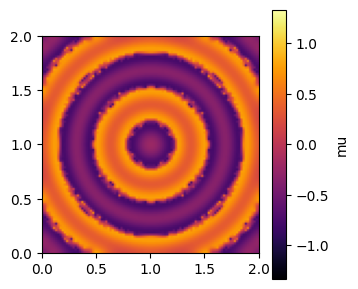

In [ ]:
os.makedirs(f"{PDE}/data", exist_ok=True)
os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}", exist_ok=True)
os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}", exist_ok=True)

for n_sources in N_SOURCES:

    os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}", exist_ok=True)
    
    for j in range(N_REPETITIONS):

        os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}", exist_ok=True)
        os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/plots", exist_ok=True)

        np.random.seed(SEED + j)
        
        A0s = np.array([0 for _ in range(N_TASKS)])
        A0xs = np.array([0 for _ in range(N_TASKS)])
        A0ys = np.array([0 for _ in range(N_TASKS)])
        B0s = np.array([0 for _ in range(N_TASKS)])
        B0xs = np.array([0 for _ in range(N_TASKS)])
        B0ys = np.array([0 for _ in range(N_TASKS)])
        C0xs = np.array([0 for _ in range(N_TASKS)])
        C0ys = np.array([0 for _ in range(N_TASKS)])
        D0s = np.array([0 for _ in range(N_TASKS)])
        centers = np.array([0 for _ in range(N_TASKS)])
        amps = np.array([0 for _ in range(N_TASKS)])
        sigmas = np.array([0 for _ in range(N_TASKS)])

        if "IC" in TO_FIX:
            if GAUSSIAN_SOURCES:
                centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources, 2))
                amps = np.random.uniform(AMP_MIN, AMP_MAX, size=(n_sources, 1))
                sigmas = np.random.uniform(STDDEV_MIN, STDDEV_MAX, size=(n_sources, 1))
                centers = np.concatenate([centers for _ in range(N_TASKS)], axis=0)
                amps = np.concatenate([amps for _ in range(N_TASKS)], axis=0)
                sigmas = np.concatenate([sigmas for _ in range(N_TASKS)], axis=0)
            if PERIODIC_CIRCLES:
                A0 = np.random.uniform(A0_MIN, A0_MAX, size=(1, 1))
                B0 = np.random.uniform(B0_MIN, B0_MAX, size=(1, 1))
                C0x, C0y = np.random.uniform(C0_MIN, C0_MAX, size=(2, 1))
                D0 = np.random.uniform(D0_MIN, D0_MAX, size=(1, 1))
                A0s = np.array([A for _ in range(N_TASKS)])
                B0s = np.array([B for _ in range(N_TASKS)])
                C0xs = np.array([Cx for _ in range(N_TASKS)])
                C0ys = np.array([Cy for _ in range(N_TASKS)])
                D0s = np.array([D for _ in range(N_TASKS)])
            if PERIODIC_VALLEYS:
                A0 = np.random.uniform(A0_MIN, A0_MAX, size=(1, 1))
                B0 = np.random.uniform(B0_MIN, B0_MAX, size=(1, 1))
                A0s = np.array([A for _ in range(N_TASKS)])
                B0s = np.array([B for _ in range(N_TASKS)])
            if PERIODIC_STRIPES:
                A0 = np.random.uniform(A0_MIN, A0_MAX, size=(1, 1))
                B0x, By = np.random.uniform(B0_MIN, B0_MAX, size=(2, 1))
                A0s = np.array([A for _ in range(N_TASKS)])
                B0xs = np.array([Bx for _ in range(N_TASKS)])
                B0ys = np.array([By for _ in range(N_TASKS)])
            if PERIODIC_GRID:
                A0x, A0y = np.random.uniform(A0_MIN, A0_MAX, size=(2, 1))
                B0x, B0y = np.random.uniform(B0_MIN, B0_MAX, size=(2, 1))
                C0x, C0y = np.random.uniform(C0_MIN, C0_MAX, size=(2, 1))
                A0xs = np.array([A0x for _ in range(N_TASKS)])
                A0ys = np.array([A0y for _ in range(N_TASKS)])
                B0xs = np.array([B0x for _ in range(N_TASKS)])
                B0ys = np.array([B0y for _ in range(N_TASKS)])
                C0xs = np.array([C0x for _ in range(N_TASKS)])
                C0ys = np.array([C0y for _ in range(N_TASKS)])
        else:
            if GAUSSIAN_SOURCES:
                if FIX_SOURCES_POSITION:
                    centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources, 2))
                    centers = np.concatenate([centers for _ in range(N_TASKS)], axis=0)
                else:
                    centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources * N_TASKS, 2))
                amps = np.random.uniform(AMP_MIN, AMP_MAX, size=(n_sources * N_TASKS, 1))
                sigmas = np.random.uniform(STDDEV_MIN, STDDEV_MAX, size=(n_sources * N_TASKS, 1))
            if PERIODIC_CIRCLES:
                A0s = np.random.uniform(A0_MIN, A0_MAX, size=(1, N_TASKS))
                B0s = np.random.uniform(B0_MIN, B0_MAX, size=(1, N_TASKS))
                C0xs, C0ys = np.random.uniform(C0_MIN, C0_MAX, size=(2, N_TASKS))
                D0s = np.random.uniform(D0_MIN, D0_MAX, size=(1, N_TASKS))
            if PERIODIC_VALLEYS:
                A0s = np.random.uniform(A0_MIN, A0_MAX, size=(1, N_TASKS))
                B0s = np.random.uniform(B0_MIN, B0_MAX, size=(1, N_TASKS))
            if PERIODIC_STRIPES:
                A0s = np.random.uniform(A0_MIN, A0_MAX, size=(1, N_TASKS))
                B0xs, B0ys = np.random.uniform(B0_MIN, B0_MAX, size=(2, N_TASKS))
            if PERIODIC_GRID:
                A0xs, A0ys = np.random.uniform(A0_MIN, A0_MAX, size=(2, N_TASKS))
                B0xs, B0ys = np.random.uniform(B0_MIN, B0_MAX, size=(2, N_TASKS))
                C0xs, C0ys = np.random.uniform(C0_MIN, C0_MAX, size=(2, N_TASKS))

        if "D" in TO_FIX:
            D1 = np.random.uniform(D1_MIN, D1_MAX, size=(1, 1))
            D1s = np.array([D1 for _ in range(N_TASKS)])
            A1 = np.random.uniform(A1_MIN, A1_MAX, size=(1, 1))
            A1s = np.array([A1 for _ in range(N_TASKS)])
            B1 = np.random.uniform(B1_MIN, B1_MAX, size=(1, 1))
            B1s = np.array([B1 for _ in range(N_TASKS)])
        else:
            D1s = np.random.uniform(D1_MIN, D1_MAX, size=(1, N_TASKS))
            A1s = np.random.uniform(A1_MIN, A1_MAX, size=(1, N_TASKS))
            B1s = np.random.uniform(B1_MIN, B1_MAX, size=(1, N_TASKS))

        centerss = [[] for _ in range(N_TASKS)]
        ampss = [[] for _ in range(N_TASKS)]
        sigmass = [[] for _ in range(N_TASKS)]

        for i in range(N_TASKS):
            centerss[i] = centers[i*n_sources : (i+1)*n_sources]
            ampss[i] = amps[i*n_sources : (i+1)*n_sources]
            sigmass[i] = sigmas[i*n_sources : (i+1)*n_sources]

        ranges = {
            "x": [X_MIN, X_MAX], 
            "y": [Y_MIN, Y_MAX]
        }
        steps = {
            "dx": DX,
            "dy": DY
        }
        circle = {
            "cell_size": CELL_SIZE, 
            "radius": RADIUS
        }

        space = {
            "mode": "grid",
            "shape": SHAPE,
            "ranges": ranges,
            "steps": steps,
            "circle": circle
        }
        
        if TIME_SAMPLING == "Const":
            time = {"t": [T_MIN, T_MAX], "dt": DT, "n_snapshots": N_TIME_SAMPLES, "snapshot_start": SNAPSHOT_START}
        elif TIME_SAMPLING == "Log":
            time = {"t": [T_MIN, T_MAX], "dt": DT, "snapshots": 2 * np.logspace(start=-2, stop=0, num=N_TIME_SAMPLES)}

        config_dict = {
            "PDE": PDE_NAME,
            "space": space,
            "time": time,
            "seed": SEED,
            "boundary_conditions": BC
        }

        initial_conditions = {
            "u0": U0,
            "gaussian": GAUSSIAN_SOURCES,
            "periodic_circles": PERIODIC_CIRCLES,
            "periodic_valleys": PERIODIC_VALLEYS,
            "periodic_stripes": PERIODIC_STRIPES,
            "periodic_grid": PERIODIC_GRID,
            "uniform_noise": UNIFORM_NOISE,
            "min_noise": NOISE_MIN,
            "max_noise": NOISE_MAX
        }

        full_datasets = []

        for k, (centers, amps, sigmas, A0, A0x, A0y, B0, B0x, B0y, C0x, C0y, D0, D1, A1, B1) in enumerate(zip(centerss, ampss, sigmass, A0s, A0xs, A0ys, B0s, B0xs, B0ys, C0xs, C0ys, D0s, D1s, A1s, B1s)):

            for i, (center, amp, sigma) in enumerate(zip(centers, amps, sigmas)):
                initial_conditions[f"xc{i}"] = center[0]
                initial_conditions[f"yc{i}"] = center[1]
                initial_conditions[f"amp{i}"] = amp
                initial_conditions[f"sigma{i}"] = sigma
            initial_conditions["A"] = A0
            initial_conditions["Ax"] = A0x
            initial_conditions["Ay"] = A0y
            initial_conditions["B"] = B0
            initial_conditions["Bx"] = B0x
            initial_conditions["By"] = B0y
            initial_conditions["Cx"] = C0x
            initial_conditions["Cy"] = C0y
            initial_conditions["D"] = D0
            config_dict["initial_conditions"] = initial_conditions

            config_dict["parameters"] = {
                "D": D1,
                "A": A1,
                "B": B1,
                "source_mode": "CahnHiliard"
            }

            full_datasets.append(
                subsample_single(
                    dataset=generate_from_config(config_dict),
                    n_samples=SAMPLES_PER_T,
                    seed=SEED
                )
            )

            to_save = {
                "initial_conditions": {
                    "u0": U0,
                    "gaussian": GAUSSIAN_SOURCES,
                    "periodic_circles": PERIODIC_CIRCLES,
                    "periodic_valleys": PERIODIC_VALLEYS,
                    "periodic_stipes": PERIODIC_STRIPES,
                    "periodic_grid": PERIODIC_GRID,
                    "uniform_noise": UNIFORM_NOISE,
                    "noise_min": NOISE_MAX,
                    "noise_max": NOISE_MIN,
                    "amps": amps.flatten().tolist(),
                    "sigmas": sigmas.flatten().tolist(),
                    "As": A0s.flatten().tolist(),
                    "Axs": A0xs.flatten().tolist(),
                    "Ays": A0ys.flatten().tolist(),
                    "Bs": B0s.flatten().tolist(),
                    "Bxs": B0xs.flatten().tolist(),
                    "Bys": B0ys.flatten().tolist(),
                    "Ds": D0s.flatten().tolist()
                },
                "parameters": {
                    "D": D1s.flatten().tolist(),
                    "A": A1s.flatten().tolist(),
                    "B": B1s.flatten().tolist(),
                }
            }

            with open(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/sample{k}.yaml", "w") as f:
                yaml.dump(to_save, f)

        # Save the datasets list as a ConcatDataset
        torch.save(ConcatDataset(full_datasets), f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/{DATASET_NAME}.pth")
        del full_datasets

10


FileNotFoundError: [Errno 2] No such file or directory: 'AdvectionReactionDiffusion/AllenCahn/data/rectangle/VaryIC_VaryD/0sources_ConstTimeStep_0-9/rep0/plots/sample0.png'

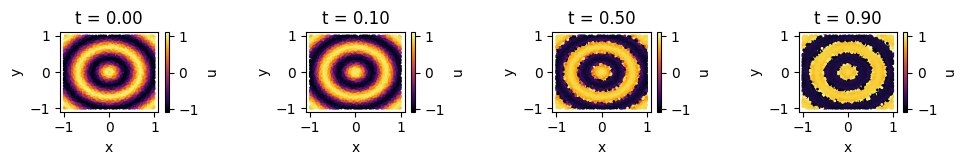

In [ ]:
reps = [0]
samples = [0]
n_sources = N_SOURCES[0]
ts = [0, 1, 5, 9]
# -------------
for rep in reps:
    for sample in samples:
        titles = f"sample {sample}\n"
        datasets = torch.load(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{rep}/{DATASET_NAME}.pth", weights_only=False).datasets[sample]
        print(len(datasets.datasets))

        for key_id, key_val in zip(
            datasets.datasets[0].tensors[IC_KEYS][0],
            datasets.datasets[0].tensors[IC_VALUES][0]
            ):
            if key_id != -1:
                key_name = ic_key_str(key_id, "Advection-Reaction-Diffusion")
                titles += f"{key_name} = {key_val:.2f}\n"
        for key_id, key_val in zip(
            datasets.datasets[0].tensors[PDE_KEYS][0],
            datasets.datasets[0].tensors[PDE_VALUES][0]
            ):
            if key_id != -1:
                key_name = key_str(key_id, "Advection-Reaction-Diffusion")
                titles += f"{key_name} = {key_val:.2f}\n"

        subtitles = [f"t = {datasets.datasets[t].tensors[TIMES][0].item():.2f}" for t in ts]
        datas = [datasets.datasets[t] for t in range(max(ts)+1)]

        del datasets

        vmin = min([datas[t].tensors[U].min() for t in ts])
        vmax = max([datas[t].tensors[U].max() for t in ts])

        # Plot
        figsize = (len(ts) * 2.5, 1.9)
        #vmin = min([dsl.datasets[t].tensors[U].min() for dsl in datasets])
        #vmax = max([dsl.datasets[t].tensors[U].max() for dsl in datasets])
        plot_points(
            dataset=[datas[t] for t in ts],#[ds.datasets[t] for ds in datasets],
            points_idx=X,
            labels_idx=U,
            #title=f"Sample {sample}",
            #caption=titles,
            subtitles=subtitles,
            single_row=True,
            cmap="inferno",
            figsize=figsize,
            vmin=len(datas)*[vmin],
            vmax=len(datas)*[vmax],
            save=True,
            dst_file=f"{PDE}/data/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{rep}/plots/sample{sample}.png",
            show=True
        )
        del datas

In [ ]:
for n_sources in N_SOURCES:
    for j in range(N_REPETITIONS):
        datasets = torch.load(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/{DATASET_NAME}.pth", weights_only=False).datasets

        dev_datasets, dev_indices, _, intra_test_indices = subsample(
            datasets,
            N_DEV_SAMPLES_PER_T,
            N_INTRA_TEST_SAMPLES_PER_T,
            seed=SEED
        )
        del datasets

        _, train_indices, _, val_indices = split_train_val(
            dev_datasets,
            N_VAL_SAMPLES_PER_T,
            seed=SEED
        )
        del dev_datasets

        n_tasks = len(train_indices) # number of tasks
        n_test_tasks = 0 #int(0.2 * n_tasks)
        n_train_tasks = n_tasks - n_test_tasks

        if n_test_tasks != 0:
            inter_test_indices = dev_indices[n_train_tasks:]

        dev_indices = dev_indices[:n_train_tasks]
        train_indices = train_indices[:n_train_tasks]
        val_indices = val_indices[:n_train_tasks]
        intra_test_indices = intra_test_indices[:n_train_tasks]

        torch.save(dev_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/dev_indices.pth")
        torch.save(train_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/train_indices.pth")
        torch.save(val_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/val_indices.pth")
        torch.save(intra_test_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/intra_test_indices.pth")
        #torch.save(inter_test_indices, f"{PDE}/data/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep/rep{j}/inter_test_indices.pth")

print(f"|dev| = {len(dev_indices[0][0])} spatial points x {len(dev_indices[0])} temporal points x {len(dev_indices)} tasks")
print(f"|train| = {len(train_indices[0][0])} spatial points x {len(train_indices[0])} temporal points x {len(train_indices)} tasks")
print(f"|val| = {len(val_indices[0][0])} spatial points x {len(val_indices[0])} temporal points x {len(val_indices)} tasks")
if n_test_tasks != 0:
    print(f"|intra_test| = {len(intra_test_indices[0][0])} spatial points x {len(intra_test_indices[0])} temporal points x {len(intra_test_indices)} tasks")
#print(f"|inter_test| = {len(inter_test_indices[0][0])} spatial points x {len(inter_test_indices[0])} temporal points x {len(inter_test_indices)} tasks")

|dev| = 2048 spatial points x 10 temporal points x 1 tasks
|train| = 1536 spatial points x 10 temporal points x 1 tasks
|val| = 512 spatial points x 10 temporal points x 1 tasks
